In [46]:
# Momentum Gradient Descent
# 
# In this notebook:
# - Implement SGD (noisy updates)
# - Implement Momentum GD (smoothed updates)
# - Compare both using cost vs epochs

In [ ]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

In [47]:
# Creating simple linear data with noise
# y = 3x + 5 + noise
# noise added to simulate real-world data

np.random.seed(42)

X = np.linspace(1, 10, 100)
y = 3*X + 5 + np.random.randn(100)*8   # higher noise

X = X.reshape(-1, 1)

# add bias
X = np.c_[np.ones(X.shape[0]), X]

In [48]:
# Stochastic Gradient Descent (SGD)

# Updates weights using one data point at a time

# This causes noisy / zig-zag updates

w_sgd = np.zeros(X.shape[1])
lr = 0.001
epochs = 75

sgd_costs = []

for epoch in range(epochs):
    for i in range(len(y)):
        xi = X[i].reshape(1, -1)
        yi = y[i]

        pred = xi @ w_sgd
        error = pred - yi

        gradient = xi.T * error
        w_sgd = w_sgd - lr * gradient.flatten()

    # full dataset cost
    preds = X @ w_sgd
    cost = np.mean((preds - y)**2)
    sgd_costs.append(cost)

In [49]:
# Momentum Gradient Descent
# Adds velocity term to remember previous gradients
# Helps reduce zig-zag and speeds up convergence

w_mom = np.zeros(X.shape[1])
v = np.zeros(X.shape[1])

beta = 0.4
lr = 0.001

momentum_costs = []

for epoch in range(epochs):
    for i in range(len(y)):
        xi = X[i].reshape(1, -1)
        yi = y[i]

        pred = xi @ w_mom
        error = pred - yi

        gradient = xi.T * error

        # momentum 
        v = beta * v + gradient.flatten()
        w_mom = w_mom - lr * v

    # full dataset cost
    preds = X @ w_mom
    cost = np.mean((preds - y)**2)
    momentum_costs.append(cost)

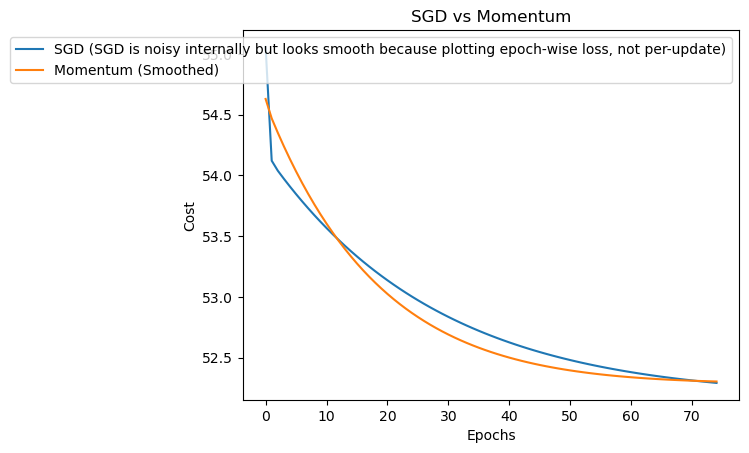

In [ ]:
# Plot cost vs epochs for SGD and Momentum
plt.plot(sgd_costs, label="SGD (SGD is noisy internally but looks smooth because plotting epoch-wise loss, not per-update)")
plt.plot(momentum_costs, label="Momentum (Smoothed)")

plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("SGD vs Momentum")

plt.legend()
plt.show()